In [1]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import pandas as pd
from transformers import BertTokenizer, BertModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

In [2]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
DATASET_NUM = 1

train = pd.read_csv(f'train_processed({DATASET_NUM}).csv')
val   = pd.read_csv(f'val_processed({DATASET_NUM}).csv')
test  = pd.read_csv(f'test_processed({DATASET_NUM}).csv')


def standardise(df):
    df = df.rename(columns={
        'Ori_Review': 'text',
        'text_': 'text',
        'Label': 'label'
    })
    return df[['text', 'Processed_Review', 'label']]

train = standardise(train)
val   = standardise(val)
test  = standardise(test)

# Fill NaN
for df in [train, val, test]:
    df['text'] = df['text'].fillna('')
    df['Processed_Review'] = df['Processed_Review'].fillna('')

print(f"Dataset {DATASET_NUM} loaded.")
print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print(train['label'].value_counts())
print(val['label'].value_counts())
print(test['label'].value_counts())

Dataset 1 loaded.
Train: (17180, 3), Val: (2148, 3), Test: (2148, 3)
label
0    10066
1     7114
Name: count, dtype: int64
label
0    1258
1     890
Name: count, dtype: int64
label
0    1259
1     889
Name: count, dtype: int64


In [4]:
tokeniser = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
bert_model = bert_model.cuda()

def get_bert_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokeniser(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors='pt'
        )
        encoded = {k: v.cuda() for k, v in encoded.items()}
        with torch.no_grad():
            outputs = bert_model(**encoded)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
        if i % 1000 == 0:
            print(f"  Processed {i}/{len(texts)} reviews")
    return np.vstack(all_embeddings)

print("Generating train BERT embeddings...")
train_bert = get_bert_embeddings(train['text'].tolist())

print("Generating val BERT embeddings...")
val_bert = get_bert_embeddings(val['text'].tolist())

print("Generating test BERT embeddings...")
test_bert = get_bert_embeddings(test['text'].tolist())

print("BERT Embeddings Done.")
print("Train shape:", train_bert.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating train BERT embeddings...
  Processed 0/17180 reviews
  Processed 4000/17180 reviews
  Processed 8000/17180 reviews
  Processed 12000/17180 reviews
  Processed 16000/17180 reviews
Generating val BERT embeddings...
  Processed 0/2148 reviews
Generating test BERT embeddings...
  Processed 0/2148 reviews
BERT Embeddings Done.
Train shape: (17180, 768)


In [5]:
# Fill NaN in processed review
train['Processed_Review'] = train['Processed_Review'].fillna('')
val['Processed_Review']   = val['Processed_Review'].fillna('')
test['Processed_Review']  = test['Processed_Review'].fillna('')

# TF-IDF fitted on training set only
tfidf = TfidfVectorizer(max_features=5000)
train_tfidf = tfidf.fit_transform(train['Processed_Review'].tolist())
val_tfidf   = tfidf.transform(val['Processed_Review'].tolist())
test_tfidf  = tfidf.transform(test['Processed_Review'].tolist())

# Dimensionality reduction
svd = TruncatedSVD(n_components=50)
train_tfidf_reduced = svd.fit_transform(train_tfidf)
val_tfidf_reduced   = svd.transform(val_tfidf)
test_tfidf_reduced  = svd.transform(test_tfidf)

# Concatenate BERT + TF-IDF
train_combined = np.concatenate([train_bert, train_tfidf_reduced], axis=1)
val_combined   = np.concatenate([val_bert,   val_tfidf_reduced],   axis=1)
test_combined  = np.concatenate([test_bert,  test_tfidf_reduced],  axis=1)

print("Train Combined Shape:", train_combined.shape)
print("Val Combined Shape:",   val_combined.shape)
print("Test Combined Shape:",  test_combined.shape)

Train Combined Shape: (17180, 818)
Val Combined Shape: (2148, 818)
Test Combined Shape: (2148, 818)


In [6]:
embedding_dim = 818
latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + embedding_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.ReLU(),
            nn.Linear(768, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, noise, embeddings):
        x = torch.cat([noise, embeddings], dim=1)
        return self.model(x)

class DiscriminatorD(nn.Module):
    def __init__(self):
        super(DiscriminatorD, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

class DiscriminatorDPrime(nn.Module):
    def __init__(self):
        super(DiscriminatorDPrime, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)


generator = Generator().cuda()
discriminator_d = DiscriminatorD().cuda()
discriminator_dprime = DiscriminatorDPrime().cuda()


def smooth_labels_like(logits, positive=True, smoothing=0.1):
    if positive:
        low, high = 1.0 - smoothing, 1.0
    else:
        low, high = 0.0, smoothing
    return torch.empty_like(logits).uniform_(low, high)


def batch_moment_loss(generated, reference):
    gen_mean = generated.mean(dim=0)
    ref_mean = reference.mean(dim=0)
    gen_std = generated.std(dim=0, unbiased=False)
    ref_std = reference.std(dim=0, unbiased=False)
    return F.mse_loss(gen_mean, ref_mean) + F.mse_loss(gen_std, ref_std)


def diversity_regularizer(samples, margin=0.35):
    if samples.size(0) < 2:
        return samples.new_tensor(0.0)
    normalised = F.normalize(samples, p=2, dim=1)
    shuffled = normalised[torch.randperm(normalised.size(0), device=normalised.device)]
    pair_distance = torch.norm(normalised - shuffled, dim=1)
    return F.relu(margin - pair_distance).mean()


def evaluate_discriminator(model, features_tensor, labels_array):
    model.eval()
    with torch.no_grad():
        scores = model(features_tensor.cuda()).cpu().numpy().flatten()
    probs = 1 / (1 + np.exp(-scores))
    preds = (probs >= 0.5).astype(int)
    val_acc = accuracy_score(labels_array, preds)
    bal_val_acc = balanced_accuracy_score(labels_array, preds)
    return val_acc, bal_val_acc, probs, preds

print("Generator:", generator)
print("Discriminator D:", discriminator_d)
print("Discriminator D':", discriminator_dprime)

Generator: Generator(
  (model): Sequential(
    (0): Linear(in_features=918, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=768, bias=True)
    (4): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=768, out_features=512, bias=True)
    (7): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (8): ReLU()
    (9): Linear(in_features=512, out_features=818, bias=True)
  )
)
Discriminator D: DiscriminatorD(
  (model): Sequential(
    (0): Linear(in_features=818, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)
Discriminator D': DiscriminatorDPrime(
  (model): Sequential(


In [7]:
print("Pre-Training Discriminator D")

pos_count = train['label'].sum()
neg_count = len(train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).cuda()


supervised_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
adv_criterion = nn.BCEWithLogitsLoss()

batch_size = 64
pretrain_epochs = 30

train_tensor_pt = torch.FloatTensor(train_combined)
train_labels_pt = torch.FloatTensor(train['label'].values)
val_tensor_pt = torch.FloatTensor(val_combined)
val_labels_pt = val['label'].values

pretrain_opt_d = torch.optim.Adam(discriminator_d.parameters(), lr=0.0001)


baseline_best_val_acc = 0.0
baseline_best_bal_val_acc = 0.0
baseline_best_state = copy.deepcopy(discriminator_d.state_dict())

for epoch in range(pretrain_epochs):
    discriminator_d.train()
    idx = torch.randperm(train_tensor_pt.size(0))
    shuffled_x = train_tensor_pt[idx]
    shuffled_y = train_labels_pt[idx]

    running_loss = 0.0
    for i in range(0, len(shuffled_x), batch_size):
        batch_x = shuffled_x[i:i+batch_size].cuda()
        batch_y = shuffled_y[i:i+batch_size].cuda()

        pretrain_opt_d.zero_grad()
        output = discriminator_d(batch_x).squeeze()
        loss = supervised_criterion(output, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(discriminator_d.parameters(), max_norm=5.0)
        pretrain_opt_d.step()
        running_loss += loss.item()

    val_acc, bal_val_acc, _, _ = evaluate_discriminator(discriminator_d, val_tensor_pt, val_labels_pt)
    avg_loss = running_loss / max(1, int(np.ceil(len(shuffled_x) / batch_size)))

    print(
        f"D Pre-Train Epoch {epoch+1}/{pretrain_epochs} | "
        f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Bal Val Acc: {bal_val_acc:.4f}"
    )

    if bal_val_acc > baseline_best_bal_val_acc:
        baseline_best_val_acc = val_acc
        baseline_best_bal_val_acc = bal_val_acc
        baseline_best_state = copy.deepcopy(discriminator_d.state_dict())

discriminator_d.load_state_dict(baseline_best_state)

print(
    f"Best Pretrained D | Val Acc: {baseline_best_val_acc:.4f} | "
    f"Bal Val Acc: {baseline_best_bal_val_acc:.4f}"
)
print("Discriminator D Pre-Training Done!")

Pre-Training Discriminator D
D Pre-Train Epoch 1/30 | Loss: 0.7469 | Val Acc: 0.6750 | Bal Val Acc: 0.6503
D Pre-Train Epoch 2/30 | Loss: 0.7164 | Val Acc: 0.6764 | Bal Val Acc: 0.6723
D Pre-Train Epoch 3/30 | Loss: 0.7059 | Val Acc: 0.6690 | Bal Val Acc: 0.6688
D Pre-Train Epoch 4/30 | Loss: 0.7011 | Val Acc: 0.6508 | Bal Val Acc: 0.6648
D Pre-Train Epoch 5/30 | Loss: 0.6944 | Val Acc: 0.6867 | Bal Val Acc: 0.6761
D Pre-Train Epoch 6/30 | Loss: 0.6928 | Val Acc: 0.6629 | Bal Val Acc: 0.6753
D Pre-Train Epoch 7/30 | Loss: 0.6878 | Val Acc: 0.6639 | Bal Val Acc: 0.6700
D Pre-Train Epoch 8/30 | Loss: 0.6832 | Val Acc: 0.6699 | Bal Val Acc: 0.6669
D Pre-Train Epoch 9/30 | Loss: 0.6795 | Val Acc: 0.6923 | Bal Val Acc: 0.6735
D Pre-Train Epoch 10/30 | Loss: 0.6741 | Val Acc: 0.6797 | Bal Val Acc: 0.6669
D Pre-Train Epoch 11/30 | Loss: 0.6703 | Val Acc: 0.6802 | Bal Val Acc: 0.6661
D Pre-Train Epoch 12/30 | Loss: 0.6685 | Val Acc: 0.6806 | Bal Val Acc: 0.6715
D Pre-Train Epoch 13/30 | Loss: 

In [8]:
print("Pre-Training Generator on deceptive reviews")

fake_mask = train['label'].values == 1
fake_embeddings = train_combined[fake_mask]
train_tensor_fake = torch.FloatTensor(fake_embeddings)

mse_criterion = nn.MSELoss()
pretrain_opt_g = torch.optim.Adam(generator.parameters(), lr=0.0001)
gen_pretrain_epochs = 5

for epoch in range(gen_pretrain_epochs):
    generator.train()
    idx = torch.randperm(train_tensor_fake.size(0))
    shuffled_fake_tensor = train_tensor_fake[idx]

    total_loss = 0.0
    total_batches = 0

    for i in range(0, len(shuffled_fake_tensor), batch_size):
        deceptive_batch = shuffled_fake_tensor[i:i+batch_size].cuda()
        if deceptive_batch.size(0) < 2:
            continue

        noise = torch.randn(deceptive_batch.size(0), latent_dim).cuda()


        partner_idx = torch.randperm(deceptive_batch.size(0), device=deceptive_batch.device)
        partner_batch = deceptive_batch[partner_idx]
        mix_ratio = torch.empty(deceptive_batch.size(0), 1, device=deceptive_batch.device).uniform_(0.60, 0.85)
        target_batch = mix_ratio * deceptive_batch + (1.0 - mix_ratio) * partner_batch

        generated = generator(noise, deceptive_batch)

        target_match_loss = mse_criterion(generated, target_batch)
        cosine_loss = 1.0 - F.cosine_similarity(generated, target_batch, dim=1).mean()
        stats_loss = batch_moment_loss(generated, deceptive_batch)
        diversity_loss = diversity_regularizer(generated)


        loss = (
            0.55 * target_match_loss
            + 0.25 * cosine_loss
            + 0.15 * stats_loss
            + 0.05 * diversity_loss
        )

        pretrain_opt_g.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=5.0)
        pretrain_opt_g.step()

        total_loss += loss.item()
        total_batches += 1

    avg_loss = total_loss / max(1, total_batches)
    print(f"Gen Pre-Train Epoch {epoch+1}/{gen_pretrain_epochs} | Loss: {avg_loss:.4f}")

print("Generator Pre-Training Done!")

Pre-Training Generator on deceptive reviews
Gen Pre-Train Epoch 1/5 | Loss: 0.0937
Gen Pre-Train Epoch 2/5 | Loss: 0.0355
Gen Pre-Train Epoch 3/5 | Loss: 0.0293
Gen Pre-Train Epoch 4/5 | Loss: 0.0258
Gen Pre-Train Epoch 5/5 | Loss: 0.0235
Generator Pre-Training Done!


In [9]:
print("Pre-Training Discriminator D'")

pretrain_opt_dprime = torch.optim.Adam(discriminator_dprime.parameters(), lr=0.0001)

for epoch in range(pretrain_epochs):
    discriminator_dprime.train()
    idx = torch.randperm(train_tensor_fake.size(0))
    shuffled_fake_tensor = train_tensor_fake[idx]

    running_loss = 0.0
    total_batches = 0

    for i in range(0, len(shuffled_fake_tensor), batch_size):
        deceptive_batch = shuffled_fake_tensor[i:i+batch_size].cuda()
        if deceptive_batch.size(0) == 0:
            continue

        noise = torch.randn(deceptive_batch.size(0), latent_dim).cuda()

        with torch.no_grad():
            generated_batch = generator(noise, deceptive_batch)

        pretrain_opt_dprime.zero_grad()

        real_logits_dp = discriminator_dprime(deceptive_batch)
        fake_logits_dp = discriminator_dprime(generated_batch)

        real_labels_dp = smooth_labels_like(real_logits_dp, positive=True, smoothing=0.1)
        fake_labels_dp = smooth_labels_like(fake_logits_dp, positive=False, smoothing=0.1)

        real_loss = adv_criterion(real_logits_dp, real_labels_dp)
        fake_loss = adv_criterion(fake_logits_dp, fake_labels_dp)
        loss = 0.5 * (real_loss + fake_loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(discriminator_dprime.parameters(), max_norm=5.0)
        pretrain_opt_dprime.step()

        running_loss += loss.item()
        total_batches += 1

    avg_loss = running_loss / max(1, total_batches)
    print(f"D' Pre-Train Epoch {epoch+1}/{pretrain_epochs} | Loss: {avg_loss:.4f}")

print("Discriminator D' Pre-Training Done!")

Pre-Training Discriminator D'
D' Pre-Train Epoch 1/30 | Loss: 0.6246
D' Pre-Train Epoch 2/30 | Loss: 0.3390
D' Pre-Train Epoch 3/30 | Loss: 0.2347
D' Pre-Train Epoch 4/30 | Loss: 0.2185
D' Pre-Train Epoch 5/30 | Loss: 0.2124
D' Pre-Train Epoch 6/30 | Loss: 0.2115
D' Pre-Train Epoch 7/30 | Loss: 0.2095
D' Pre-Train Epoch 8/30 | Loss: 0.2061
D' Pre-Train Epoch 9/30 | Loss: 0.2074
D' Pre-Train Epoch 10/30 | Loss: 0.2048
D' Pre-Train Epoch 11/30 | Loss: 0.2040
D' Pre-Train Epoch 12/30 | Loss: 0.2053
D' Pre-Train Epoch 13/30 | Loss: 0.2039
D' Pre-Train Epoch 14/30 | Loss: 0.2036
D' Pre-Train Epoch 15/30 | Loss: 0.2029
D' Pre-Train Epoch 16/30 | Loss: 0.2051
D' Pre-Train Epoch 17/30 | Loss: 0.2039
D' Pre-Train Epoch 18/30 | Loss: 0.2029
D' Pre-Train Epoch 19/30 | Loss: 0.2033
D' Pre-Train Epoch 20/30 | Loss: 0.2026
D' Pre-Train Epoch 21/30 | Loss: 0.2032
D' Pre-Train Epoch 22/30 | Loss: 0.2020
D' Pre-Train Epoch 23/30 | Loss: 0.2023
D' Pre-Train Epoch 24/30 | Loss: 0.2020
D' Pre-Train Epoch 

In [10]:
print("Starting Adversarial Training")

opt_g = torch.optim.Adam(generator.parameters(), lr=0.00005, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator_d.parameters(), lr=0.000005, betas=(0.5, 0.999))
opt_dprime = torch.optim.Adam(discriminator_dprime.parameters(), lr=0.00001, betas=(0.5, 0.999))

n_epochs = 50
g_steps = 1
d_steps = 4
patience = 20

train_tensor = torch.FloatTensor(train_combined)
train_labels = torch.FloatTensor(train['label'].values)
val_tensor = torch.FloatTensor(val_combined)
val_labels = val['label'].values
fake_tensor = torch.FloatTensor(train_combined[fake_mask])


best_val_acc = baseline_best_bal_val_acc
epochs_no_improve = 0
best_model_weights = copy.deepcopy(discriminator_d.state_dict())

d_losses, g_losses, val_accs = [], [], []

for epoch in range(n_epochs):
    idx = torch.randperm(train_tensor.size(0))
    shuffled_train = train_tensor[idx]
    shuffled_labels = train_labels[idx]

    discriminator_d.train()
    discriminator_dprime.train()
    generator.train()

    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_dprime_loss = 0.0
    epoch_batches = 0

    for i in range(0, len(shuffled_train), batch_size):
        real_batch = shuffled_train[i:i+batch_size].cuda()
        real_batch_labels = shuffled_labels[i:i+batch_size].cuda()
        batch_len = real_batch.size(0)

        if batch_len < 2:
            continue


        deceptive_idx = torch.randint(0, fake_tensor.size(0), (batch_len,))
        deceptive_batch = fake_tensor[deceptive_idx].cuda()


        for _ in range(g_steps):
            opt_g.zero_grad()

            noise = torch.randn(batch_len, latent_dim).cuda()
            generated = generator(noise, deceptive_batch)

            d_logits_for_g = discriminator_d(generated)
            dprime_logits_for_g = discriminator_dprime(generated)

            g_target_d = smooth_labels_like(d_logits_for_g, positive=False, smoothing=0.1)
            g_target_dprime = smooth_labels_like(dprime_logits_for_g, positive=True, smoothing=0.1)

            g_adv_d = adv_criterion(d_logits_for_g, g_target_d)
            g_adv_dprime = adv_criterion(dprime_logits_for_g, g_target_dprime)
            g_stats = batch_moment_loss(generated, deceptive_batch)
            g_div = diversity_regularizer(generated)

            g_loss = (
                0.45 * g_adv_d
                + 0.45 * g_adv_dprime
                + 0.05 * g_stats
                + 0.05 * g_div
            )

            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=5.0)
            opt_g.step()


        for _ in range(d_steps):
            opt_d.zero_grad()

            noise = torch.randn(batch_len, latent_dim).cuda()
            generated = generator(noise, deceptive_batch).detach()

            real_logits_d = discriminator_d(real_batch).squeeze()
            fake_logits_d = discriminator_d(generated)

            real_loss = supervised_criterion(real_logits_d, real_batch_labels)
            fake_targets_d = smooth_labels_like(fake_logits_d, positive=True, smoothing=0.1)
            fake_loss_d = adv_criterion(fake_logits_d, fake_targets_d)

            d_loss = 0.70 * real_loss + 0.30 * fake_loss_d

            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator_d.parameters(), max_norm=5.0)
            opt_d.step()


        for _ in range(d_steps):
            opt_dprime.zero_grad()

            noise = torch.randn(batch_len, latent_dim).cuda()
            generated = generator(noise, deceptive_batch).detach()

            real_logits_dp = discriminator_dprime(deceptive_batch)
            fake_logits_dp = discriminator_dprime(generated)

            real_targets_dp = smooth_labels_like(real_logits_dp, positive=True, smoothing=0.1)
            fake_targets_dp = smooth_labels_like(fake_logits_dp, positive=False, smoothing=0.1)

            real_loss_dp = adv_criterion(real_logits_dp, real_targets_dp)
            fake_loss_dp = adv_criterion(fake_logits_dp, fake_targets_dp)
            dprime_loss = 0.50 * (real_loss_dp + fake_loss_dp)

            dprime_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator_dprime.parameters(), max_norm=5.0)
            opt_dprime.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_dprime_loss += dprime_loss.item()
        epoch_batches += 1

    avg_d_loss = epoch_d_loss / max(1, epoch_batches)
    avg_g_loss = epoch_g_loss / max(1, epoch_batches)
    avg_dprime_loss = epoch_dprime_loss / max(1, epoch_batches)

    val_acc, bal_val_acc, _, _ = evaluate_discriminator(discriminator_d, val_tensor, val_labels)

    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)
    val_accs.append(bal_val_acc)

    print(
        f"Epoch {epoch+1}/{n_epochs} | D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f} | D' Loss: {avg_dprime_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | Bal Val Acc: {bal_val_acc:.4f} | "
        f"Delta vs Baseline: {bal_val_acc - baseline_best_bal_val_acc:+.4f}"
    )

    if bal_val_acc > best_val_acc:
        best_val_acc = bal_val_acc
        best_model_weights = copy.deepcopy(discriminator_d.state_dict())
        epochs_no_improve = 0
        print(f"Best adversarial model saved at epoch {epoch+1} | Bal Val Acc: {best_val_acc:.4f}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

discriminator_d.load_state_dict(best_model_weights)

print(
    f"\nValidation comparison | Pretrained D: {baseline_best_bal_val_acc:.4f} | "
    f"Best Adversarial D: {best_val_acc:.4f} | Delta: {best_val_acc - baseline_best_bal_val_acc:+.4f}"
)
print("Adversarial Training Done!")

Starting Adversarial Training
Epoch 1/50 | D Loss: 1.1403 | G Loss: 0.2452 | D' Loss: 1.5906 | Val Acc: 0.6150 | Bal Val Acc: 0.6470 | Delta vs Baseline: -0.0292
Epoch 2/50 | D Loss: 0.7685 | G Loss: 0.4170 | D' Loss: 1.2772 | Val Acc: 0.6262 | Bal Val Acc: 0.6478 | Delta vs Baseline: -0.0283
Epoch 3/50 | D Loss: 0.6977 | G Loss: 0.5532 | D' Loss: 0.9432 | Val Acc: 0.6466 | Bal Val Acc: 0.6600 | Delta vs Baseline: -0.0161
Epoch 4/50 | D Loss: 0.7109 | G Loss: 0.7126 | D' Loss: 0.6847 | Val Acc: 0.5275 | Bal Val Acc: 0.5872 | Delta vs Baseline: -0.0889
Epoch 5/50 | D Loss: 0.7034 | G Loss: 0.7611 | D' Loss: 0.6281 | Val Acc: 0.5168 | Bal Val Acc: 0.5782 | Delta vs Baseline: -0.0979
Epoch 6/50 | D Loss: 0.6979 | G Loss: 0.7639 | D' Loss: 0.6308 | Val Acc: 0.5652 | Bal Val Acc: 0.6166 | Delta vs Baseline: -0.0595
Epoch 7/50 | D Loss: 0.6921 | G Loss: 0.7790 | D' Loss: 0.6173 | Val Acc: 0.5829 | Bal Val Acc: 0.6293 | Delta vs Baseline: -0.0469
Epoch 8/50 | D Loss: 0.6817 | G Loss: 0.8027 |

In [11]:
print("Evaluating on Test Set")

discriminator_d.eval()
generator.eval()

test_tensor    = torch.FloatTensor(test_combined).cuda()
test_labels_arr = test['label'].values

with torch.no_grad():
    test_scores = discriminator_d(test_tensor).cpu().numpy().flatten()

test_probs = 1 / (1 + np.exp(-test_scores))
test_preds = (test_probs >= 0.5).astype(int)

accuracy  = accuracy_score(test_labels_arr, test_preds)
bal_acc   = balanced_accuracy_score(test_labels_arr, test_preds)
precision = precision_score(test_labels_arr, test_preds, zero_division=0)
recall    = recall_score(test_labels_arr, test_preds, zero_division=0)
f1        = f1_score(test_labels_arr, test_preds, zero_division=0)
auc       = roc_auc_score(test_labels_arr, test_probs)
cm        = confusion_matrix(test_labels_arr, test_preds)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
gmean = np.sqrt(sensitivity * specificity)


print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")
print(f"G-Mean:            {gmean:.4f}")
print(f"Confusion Matrix:\n{cm}")

Evaluating on Test Set
Accuracy:          0.6909
Balanced Accuracy: 0.6819
Precision:         0.6257
Recall:            0.6299
F1 Score:          0.6278
AUC:               0.7541
G-Mean:            0.6799
Confusion Matrix:
[[924 335]
 [329 560]]


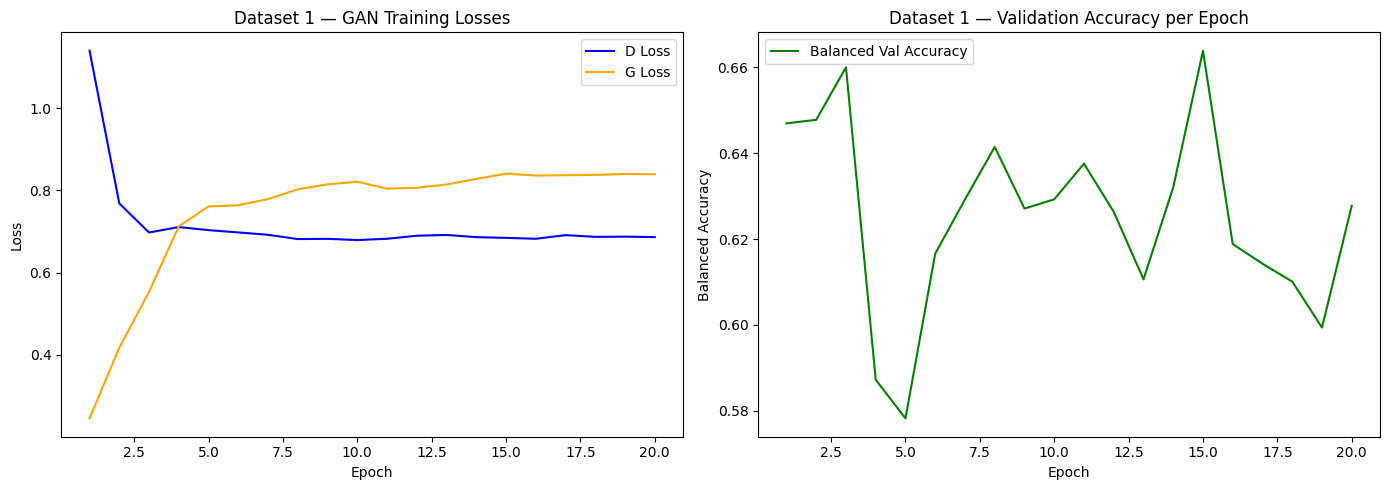

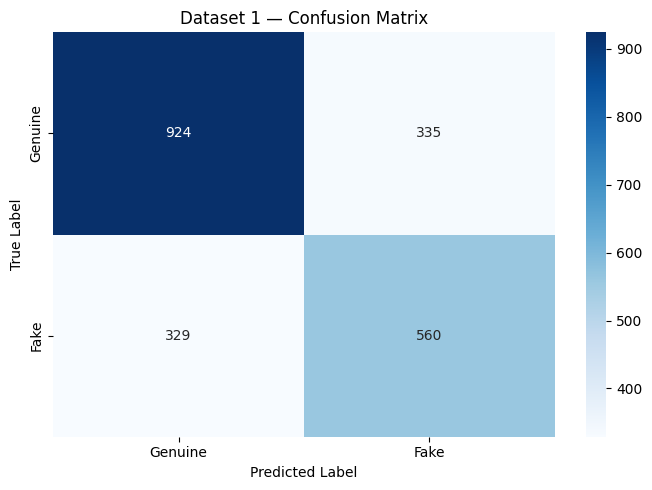

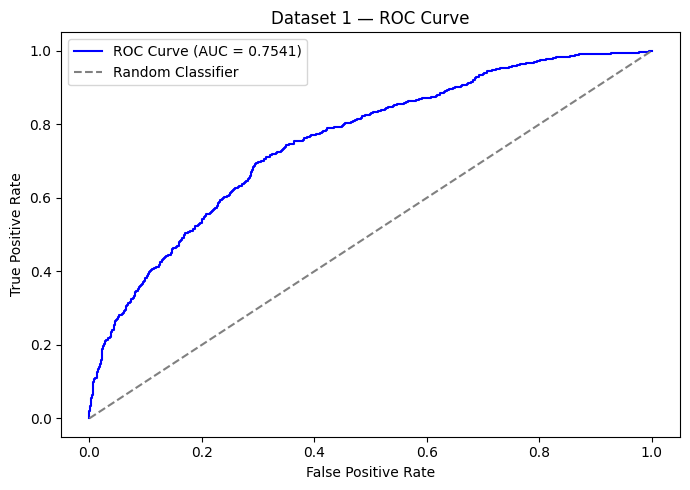

In [12]:
# Training curves
epochs_ran = list(range(1, len(d_losses) + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_ran, d_losses, label='D Loss', color='blue')
ax1.plot(epochs_ran, g_losses, label='G Loss', color='orange')
ax1.set_title(f'Dataset {DATASET_NUM} — GAN Training Losses')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax2.plot(epochs_ran, val_accs, label='Balanced Val Accuracy', color='green')
ax2.set_title(f'Dataset {DATASET_NUM} — Validation Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Balanced Accuracy')
ax2.legend()
plt.tight_layout()
plt.savefig(f'training_curves_dataset{DATASET_NUM}.png', dpi=300)
plt.show()

# Confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fake'],
            yticklabels=['Genuine', 'Fake'])
plt.title(f'Dataset {DATASET_NUM} — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'confusion_matrix_dataset{DATASET_NUM}.png', dpi=300)
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(test_labels_arr, test_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Dataset {DATASET_NUM} — ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig(f'roc_curve_dataset{DATASET_NUM}.png', dpi=300)
plt.show()